# DESPESAS POR ORGÂO

In [106]:
import pandas as pd
import glob

# caminho da pasta (relativo ao seu notebook)
caminho = "despesapororgao/*.csv"

# pega todos os arquivos CSV
arquivos = glob.glob(caminho)

df_orgao = pd.concat([
    pd.read_csv(arq, sep=";", encoding="latin1", on_bad_lines="skip")
    for arq in arquivos
], ignore_index=True)

In [107]:
df_orgao.head()

,"ï»¿""MÃªs Ano""",ÃrgÃ£o Superior,ÃrgÃ£o/Entidade Vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos,Unnamed: 7
0,03/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"48.885.924,02","349.950.597,30","352.935.287,23","7.908.354,93",NaN
1,08/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"50.420.355,12","381.683.525,18","391.800.281,58","7.085.007,38",NaN
2,05/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"256.429.018,98","368.489.588,15","376.835.253,41","1.956.849,36",NaN
3,11/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"145.771.518,23","575.189.702,95","461.785.115,16","3.109.891,42",NaN
4,10/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"148.691.378,21","412.015.051,40","398.185.846,49","4.080.277,56",NaN


In [108]:
df_orgao = df_orgao.rename(columns={
    'ï»¿"MÃªs Ano"': "mes_ano",
    "ÃrgÃ£o Superior": "orgao_superior",
    "ÃrgÃ£o/Entidade Vinculada": "entidade_vinculada",
})

df_orgao.head()

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos,Unnamed: 7
0,03/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"48.885.924,02","349.950.597,30","352.935.287,23","7.908.354,93",NaN
1,08/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"50.420.355,12","381.683.525,18","391.800.281,58","7.085.007,38",NaN
2,05/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"256.429.018,98","368.489.588,15","376.835.253,41","1.956.849,36",NaN
3,11/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"145.771.518,23","575.189.702,95","461.785.115,16","3.109.891,42",NaN
4,10/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"148.691.378,21","412.015.051,40","398.185.846,49","4.080.277,56",NaN


In [109]:
df_orgao = df_orgao.drop("Unnamed: 7", axis=1)

df_orgao.head()

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,03/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"48.885.924,02","349.950.597,30","352.935.287,23","7.908.354,93"
1,08/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"50.420.355,12","381.683.525,18","391.800.281,58","7.085.007,38"
2,05/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"256.429.018,98","368.489.588,15","376.835.253,41","1.956.849,36"
3,11/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"145.771.518,23","575.189.702,95","461.785.115,16","3.109.891,42"
4,10/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,"148.691.378,21","412.015.051,40","398.185.846,49","4.080.277,56"


## padronizar valores numericos

In [110]:
df_orgao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37030 entries, 0 to 37029
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   mes_ano                     37030 non-null  object
 1   orgao_superior              37030 non-null  object
 2   entidade_vinculada          37030 non-null  object
 3   Valor Empenhado             37030 non-null  object
 4   Valor Liquidado             37030 non-null  object
 5   Valor Pago                  37030 non-null  object
 6   Valor Restos a Pagar Pagos  37030 non-null  object
dtypes: object(7)
memory usage: 2.0+ MB


In [111]:
valores_colunas = df_orgao.columns[3:]  

for col in valores_colunas:
    df_orgao[col] = (
        df_orgao[col]
        .astype(str)
        .str.strip()                     
        .str.replace("R$", "", regex=False)  
        .str.replace(" ", "", regex=False)  
        .str.replace(".", "", regex=False)  
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df_orgao.head()

,mes_ano,orgao_superior,entidade_vinculada,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos a Pagar Pagos
0,03/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,4.888592e+07,3.499506e+08,3.529353e+08,7908354.93
1,08/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,5.042036e+07,3.816835e+08,3.918003e+08,7085007.38
2,05/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,2.564290e+08,3.684896e+08,3.768353e+08,1956849.36
3,11/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.457715e+08,5.751897e+08,4.617851e+08,3109891.42
4,10/2025,63000 - Advocacia-Geral da UniÃ£o,63000 - Advocacia-Geral da UniÃ£o - Unidades c...,1.486914e+08,4.120151e+08,3.981858e+08,4080277.56


## Padronizando data

In [112]:
print(df_orgao["mes_ano"].unique())

['03/2025' '08/2025' '05/2025' '11/2025' '10/2025' '01/2025' '02/2025'
 '04/2025' '06/2025' '12/2025' '09/2025' '07/2025' '11/2016' '05/2016'
 '04/2016' '03/2016' '06/2016' '01/2016' '08/2016' '10/2016' '02/2016'
 '09/2016' '12/2016' '07/2016' '08/2015' '03/2015' '07/2015' '10/2015'
 '12/2015' '05/2015' '04/2015' '06/2015' '01/2015' '09/2015' '11/2015'
 '02/2015' '06/2014' '08/2014' '04/2014' '10/2014' '12/2014' '09/2014'
 '02/2014' '03/2014' '05/2014' '11/2014' '07/2014' '01/2014' '01/2024'
 '02/2024' '06/2024' '12/2024' '05/2024' '07/2024' '03/2024' '09/2024'
 '08/2024' '04/2024' '11/2024' '10/2024' '12/2023' '10/2023' '11/2023'
 '05/2023' '07/2023' '03/2023' '06/2023' '04/2023' '09/2023' '01/2023'
 '08/2023' '02/2023' '09/2022' '08/2022' '01/2022' '06/2022' '11/2022'
 '10/2022' '12/2022' '04/2022' '07/2022' '02/2022' '05/2022' '03/2022'
 '10/2021' '04/2021' '05/2021' '03/2021' '08/2021' '02/2021' '06/2021'
 '11/2021' '07/2021' '01/2021' '09/2021' '12/2021' '10/2020' '03/2020'
 '05/2

In [113]:
df_orgao["mes_ano"] = pd.to_datetime(df_orgao["mes_ano"], format="%m/%Y")

In [114]:
df_orgao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37030 entries, 0 to 37029
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   mes_ano                     37030 non-null  datetime64[ns]
 1   orgao_superior              37030 non-null  object        
 2   entidade_vinculada          37030 non-null  object        
 3   Valor Empenhado             37030 non-null  float64       
 4   Valor Liquidado             37030 non-null  float64       
 5   Valor Pago                  37030 non-null  float64       
 6   Valor Restos a Pagar Pagos  37030 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 2.0+ MB


## padronizando textos

In [115]:
def corrigir_encoding(texto):
    try:
        return texto.encode('latin1').decode('utf-8')
    except:
        return texto

colunas = ["orgao_superior", "entidade_vinculada"]

for col in colunas:
    df_orgao[col] = df_orgao[col].astype(str).apply(corrigir_encoding)

In [116]:
df_orgao["entidade_vinculada"].unique()

array(['63000 - Advocacia-Geral da União - Unidades com vínculo direto',
       '20402 - Agência Espacial Brasileira',
       '62201 - Agência Nacional de Aviação Civil',
       '32210 - Agência Nacional de Energia Elétrica',
       '32396 - Agência Nacional de Mineração',
       '36213 - Agência Nacional de Saúde Suplementar',
       '68201 - Agência Nacional de Transportes Aquaviários',
       '39250 - Agência Nacional de Transportes Terrestres',
       '36212 - Agência Nacional de Vigilância Sanitária',
       '44205 - Agência Nacional de Águas e Saneamento Básico',
       '20203 - Agência Nacional do Cinema',
       '32205 - Agência Nacional do Petróleo, Gás Natural e Biocombustíveis',
       '41231 - Agêncial Nacional de Telecomunicações',
       '52233 - Amazônia Azul Tecnologia de Defesa S.A.',
       '30212 - Autoridade Nacional de Proteção de Dados',
       '25201 - Banco Central do Brasil - Orçamento Fiscal e Seguridade Social - Unidades com vínculo direto',
       '31280 - C

In [117]:
df_orgao.to_csv("despesas_por_orgao.csv", index=False, encoding="utf-8")

## Separando o investimento anual para a Ancine

In [118]:
df_ancine = df_orgao[df_orgao["entidade_vinculada"] == "20203 - Agência Nacional do Cinema"]

In [119]:
df_ancine_ano = df_ancine.groupby(df_ancine["mes_ano"].dt.year)["Valor Pago"].sum().reset_index()

In [120]:
df_ancine_ano.head(15)

,mes_ano,Valor Pago
0,2014,1.067483e+08
1,2015,1.139029e+08
2,2016,1.250283e+08
3,2017,2.078331e+08
4,2018,1.301704e+08
5,2019,1.248012e+08
6,2020,1.147594e+08
7,2021,1.164833e+08
8,2022,1.152105e+08
9,2023,1.355807e+09


In [121]:
df_ancine_ano.to_csv("despesas_ancine_ano.csv", index=False, encoding="utf-8")

## Quantos são investidos no Fundo Setorial Audiovisual

In [122]:
!pip install odfpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
# Configurações
arquivo_ods = 'relatorios/31072025_TabelasFSA.ods'
nome_da_aba = '7__Invest_'  # Nome exato que aparece na aba da imagem
arquivo_saida = 'investimentos.csv'

# Ler apenas a aba 7
df_FSA = pd.read_excel(arquivo_ods, engine='odf', sheet_name=nome_da_aba)

df_FSA.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,Investimentos Retornáveis no Setor Audiovisual...,NaN,NaN,NaN
1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados...,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000


In [124]:
df_FSA.columns = df_FSA.iloc[1]  # Define a primeira linha como cabeçalho

df_FSA.head()  # Remove as duas primeiras linhas

1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
0,NaN,Investimentos Retornáveis no Setor Audiovisual...,NaN,NaN,NaN
1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados...,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000


In [125]:
df_FSA = df_FSA.drop(index=[0, 1])  # Remove as duas primeiras linhas
df_FSA.head()  # Visualizar os dados após a remoção

1,NaN,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,NaN,2007,15000000,0,0
3,NaN,2008,38549335,38549335,0
4,NaN,2009,84904972,84904972,4500000
5,NaN,2010,54059817,0,15650780.12
6,NaN,2011,157275011,54059817,31325735.72


In [126]:
df_FSA = df_FSA.drop(df_FSA.columns[0], axis=1)  # Remove a primeira coluna
df_FSA.head()

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72


In [127]:
df_FSA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 2 to 25
Data columns (total 4 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Ano                                                      24 non-null     object
 1   Empenho do Orçamento do FSA                              20 non-null     object
 2   Execução Financeira (recursos disponibilizados ao FSA)1  20 non-null     object
 3   Recursos Desembolsados2                                  20 non-null     object
dtypes: object(4)
memory usage: 900.0+ bytes


In [128]:
df_FSA.head(30)

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72
7,2012,369190348,53309653,44587284.09
8,2013,400000000,121500000,78465397.52
9,2014,414000000,65000000,89125408.32
10,2015,500000000,487811889,218904814.15
11,2016,591765859,699782502,270558303.61


In [129]:
df_FSA = df_FSA.drop(index=df_FSA.index[19:30])
df_FSA.head(30)  # Remove as duas primeiras linhas

1,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
2,2007,15000000,0,0
3,2008,38549335,38549335,0
4,2009,84904972,84904972,4500000
5,2010,54059817,0,15650780.12
6,2011,157275011,54059817,31325735.72
7,2012,369190348,53309653,44587284.09
8,2013,400000000,121500000,78465397.52
9,2014,414000000,65000000,89125408.32
10,2015,500000000,487811889,218904814.15
11,2016,591765859,699782502,270558303.61


In [130]:
df_FSA["Ano"] = df_FSA["Ano"].str.replace(" ", "").str.replace("*", "")
df_FSA["Ano"] = pd.to_datetime(df_FSA["Ano"], format='%Y').dt.year


In [131]:
df_FSA.columns = df_FSA.columns.str.strip()

In [132]:
df_FSA["Execução Financeira (recursos disponibilizados ao FSA)1"] = df_FSA["Execução Financeira (recursos disponibilizados ao FSA)1"].astype(float)

## Os investimentos estão rendendo?

In [133]:
df_bilheteria = pd.read_csv("Bilheteria_N x Bilheteria_IN(2014-2025).csv", encoding="utf-8")

df_correlacao = pd.merge(df_ancine_ano, df_bilheteria, left_on="mes_ano", right_on="ano", how="inner")

df_correlacao = df_correlacao.drop("ano", axis=1)

df_correlacao = pd.merge(df_correlacao, df_FSA, left_on="mes_ano", right_on="Ano", how="inner")

df_correlacao.head(15)

,mes_ano,Valor Pago,bilheteria_internacional,bilheteria_nacional,Ano,Empenho do Orçamento do FSA,Execução Financeira (recursos disponibilizados ao FSA)1,Recursos Desembolsados2
0,2025,1.056417e+09,1428448862,182193506,2025.0,645000000,234000000.0,235944405


In [ ]:
df_correlacao = df_correlacao.drop(["Ano", "Empenho do Orçamento do FSA", "Recursos Desembolsados2"], axis=1)

KeyError: "['Empenho do Orçamento do FSA\\t', 'Recusos Desembolsados2'] not found in axis"

In [134]:
correlacao = df_correlacao["Valor Pago"].corr(df_correlacao["bilheteria_nacional"])
print(f"O coeficiente de correlação é: {correlacao:.2f}")

O coeficiente de correlação é: nan


c:\Users\Maria do Ceu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\Maria do Ceu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\Maria do Ceu\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


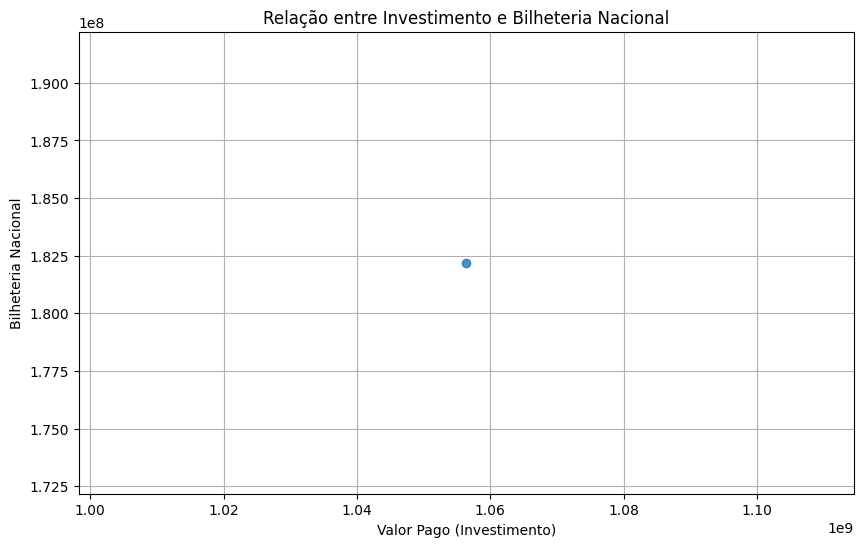

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# regplot cria o scatter plot e já desenha a linha de tendência automaticamente
sns.regplot(data=df_correlacao, x="Valor Pago", y="bilheteria_nacional")

plt.title("Relação entre Investimento e Bilheteria Nacional")
plt.xlabel("Valor Pago (Investimento)")
plt.ylabel("Bilheteria Nacional")
plt.grid(True)
plt.show()

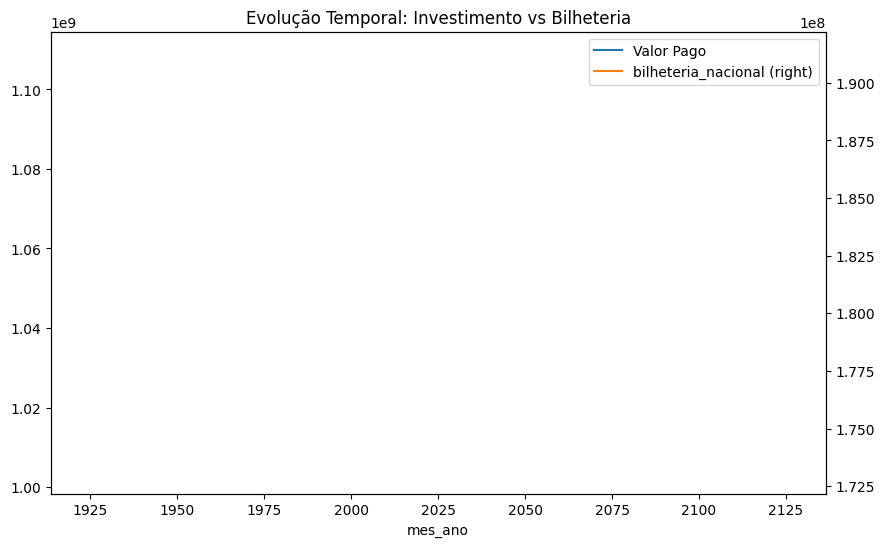

In [136]:
df_plot = df_correlacao.set_index("mes_ano")
df_plot[["Valor Pago", "bilheteria_nacional"]].plot(secondary_y="bilheteria_nacional", figsize=(10,6))
plt.title("Evolução Temporal: Investimento vs Bilheteria")
plt.show()